In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Agregasi penjualan per bulan
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()
monthly_sales.columns = ['ds', 'y']

print(monthly_sales.tail(10))
print(f"\nTotal data: {len(monthly_sales)} bulan")

           ds            y
38 2017-03-01   58872.3528
39 2017-04-01   36521.5361
40 2017-05-01   44261.1102
41 2017-06-01   52981.7257
42 2017-07-01   45264.4160
43 2017-08-01   63120.8880
44 2017-09-01   87866.6520
45 2017-10-01   77776.9232
46 2017-11-01  118447.8250
47 2017-12-01   83829.3188

Total data: 48 bulan


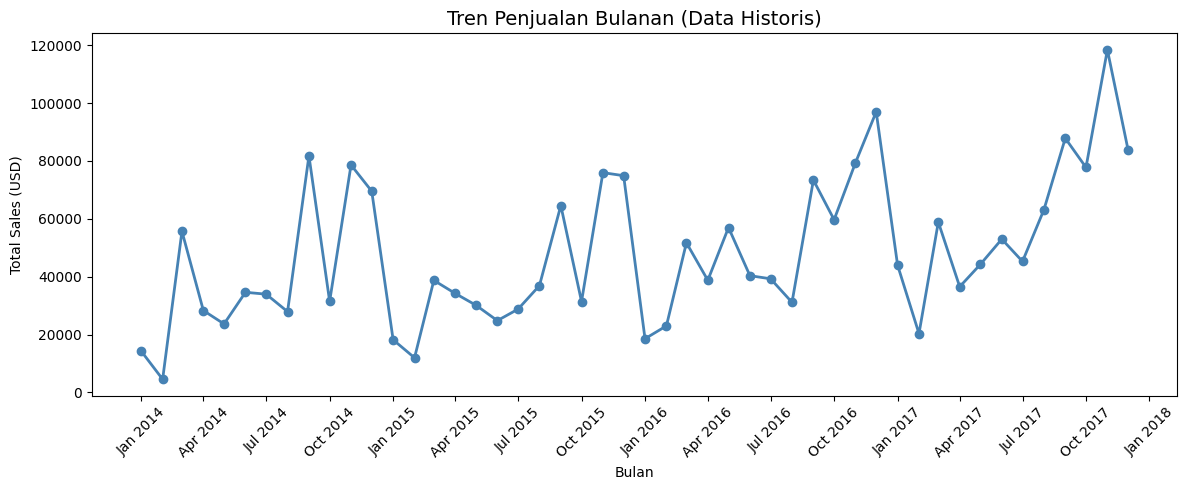

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['ds'], monthly_sales['y'], marker='o', color='steelblue', linewidth=2)
plt.title('Tren Penjualan Bulanan (Data Historis)', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Total Sales (USD)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
# Pakai Exponential Smoothing (Holt-Winters)
model = ExponentialSmoothing(
    monthly_sales['y'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Prediksi 6 bulan ke depan
forecast_steps = 6
forecast = model.forecast(forecast_steps)

# Buat dataframe hasil prediksi
last_date = monthly_sales['ds'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_df = pd.DataFrame({'ds': future_dates, 'forecast': forecast.values})

print("Prediksi 6 Bulan ke Depan:")
print(forecast_df)

Prediksi 6 Bulan ke Depan:
          ds      forecast
0 2018-01-01  49690.639698
1 2018-02-01  41838.838274
2 2018-03-01  74874.490096
3 2018-04-01  61540.065974
4 2018-05-01  68505.554365
5 2018-06-01  65396.408547


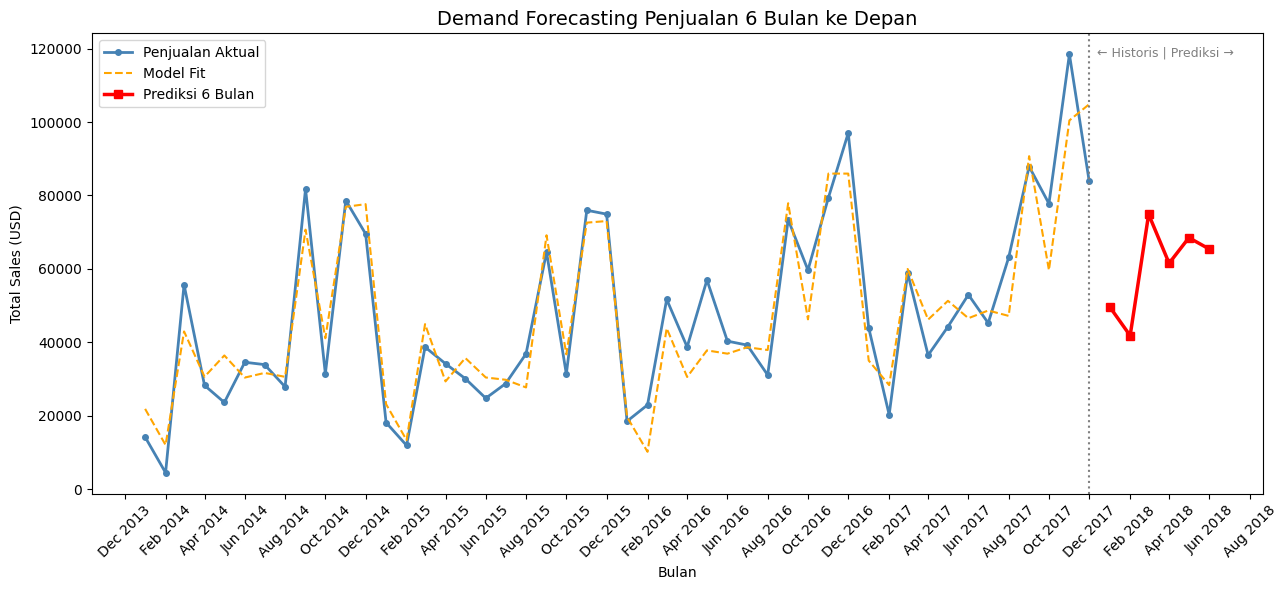

In [5]:
plt.figure(figsize=(13, 6))

# Data historis
plt.plot(monthly_sales['ds'], monthly_sales['y'], 
         label='Penjualan Aktual', color='steelblue', linewidth=2, marker='o', markersize=4)

# Fitted values (model)
plt.plot(monthly_sales['ds'], model.fittedvalues, 
         label='Model Fit', color='orange', linewidth=1.5, linestyle='--')

# Prediksi
plt.plot(forecast_df['ds'], forecast_df['forecast'], 
         label='Prediksi 6 Bulan', color='red', linewidth=2.5, marker='s', markersize=6)

# Garis pemisah historis vs prediksi
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.5)
plt.text(last_date, plt.ylim()[1]*0.95, '  ← Historis | Prediksi →', fontsize=9, color='gray')

plt.title('Demand Forecasting Penjualan 6 Bulan ke Depan', fontsize=14)
plt.xlabel('Bulan')
plt.ylabel('Total Sales (USD)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Gabungkan historis + prediksi lalu simpan
hasil_forecast = pd.DataFrame({
    'Bulan': forecast_df['ds'].dt.strftime('%B %Y'),
    'Prediksi_Sales_USD': forecast_df['forecast'].round(2)
})
print(hasil_forecast.to_string(index=False))
hasil_forecast.to_csv('hasil_forecasting.csv', index=False)
print("\n✅ File hasil_forecasting.csv berhasil disimpan!")

        Bulan  Prediksi_Sales_USD
 January 2018            49690.64
February 2018            41838.84
   March 2018            74874.49
   April 2018            61540.07
     May 2018            68505.55
    June 2018            65396.41

✅ File hasil_forecasting.csv berhasil disimpan!
